# Case Study 02: Quantile-Based Safety Stock & Financial Cost Optimization

## Executive Summary
Accurate point forecasts alone do not prevent costly stockouts or excess holding costs. Supply chain decision-makers must evaluate forecast uncertainty to set optimal inventory buffers that balance **Holding Costs** against **Stockout Penalties**.

Rather than relying on theoretical normal distribution assumptions ($Z$-scores), this case study uses empirical **Quantile Predictions ($q_{10}, q_{90}$)** from our LightGBM model. We first validate that our 80% prediction intervals are well-calibrated (achieving **89.4% empirical coverage**), and then translate the $90\text{th}$ percentile demand predictions directly into item-level safety stock buffers and financial risk metrics.

---

## Key Formulas Applied

1. **Prediction Interval Coverage (Interval Calibration):**
   $$\text{Coverage Rate} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}\left(q_{10, i} \le y_i \le q_{90, i}\right)$$
   *Ensures at least 80% of actual sales ($y_i$) fall inside the predicted $[q_{10}, q_{90}]$ range.*

2. **Quantile Safety Stock Buffer ($SS$):**
   $$SS = \max\left(0, \; q_{90} - \hat{y}\right)$$
   *Where $q_{90}$ is the 90th percentile demand prediction and $\hat{y}$ is the expected point forecast.*

3. **Financial Unit Economics:**
   * **Unit Cost:** $\text{Cost} = 0.60 \times \text{Sell Price}$
   * **Unit Profit (Stockout Penalty):** $\text{Profit} = 0.40 \times \text{Sell Price}$
   * **Daily Holding Cost Rate:** $h = \left(\frac{0.25}{365}\right) \times \text{Unit Cost}$

4. **Financial Cost Exposure:**
   * **Holding Cost:** 
     $$\text{Cost}_{\text{holding}} = h \times SS$$
   * **Stockout Cost (Lost Sales Penalty):** 
     $$\text{Cost}_{\text{stockout}} = \text{Unit Profit} \times \max\left(0, \; y - q_{90}\right)$$
   * **Total Financial Exposure:** 
     $$\text{Total Cost} = \text{Cost}_{\text{holding}} + \text{Cost}_{\text{stockout}}$$

In [6]:
import sys
from pathlib import Path

# Adds the root_dir (parent of notebooks/) to sys.path
parent_dir = str(Path().resolve().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR/"data"/"processed"


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

=== Portfolio Summary Metrics (28-Day Horizon) ===
Total Portfolio Cost Exposure: $11,272.56
Average Cost Exposure per Item: $3.70
Median Cost Exposure per Item:  $1.25

=== Cost Exposure by Product Category ===
 category  total_category_cost  avg_item_cost  item_count
    FOODS          6071.929498       4.225421        1437
  HOBBIES          1915.994131       3.391140         565
HOUSEHOLD          3284.633637       3.137186        1047


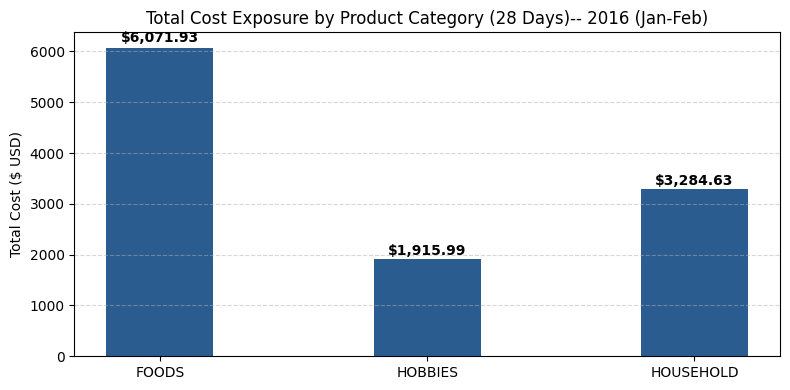

In [5]:
# cost per item already calculated file

costs_file = BASE_DIR / 'results/cost_per_items_2016_Jan_Feb.csv'

cost_summary_df = pd.read_csv(costs_file)

"""
Case Study 02 Output Formatter
Objective: Summarize item-level total costs into portfolio-level metrics 
           and department breakdowns for documentation.
"""

# -------------------------------------------------------------------------
# 1. Summary Metrics
# -------------------------------------------------------------------------
total_portfolio_cost = cost_summary_df['total_cost'].sum()
mean_item_cost = cost_summary_df['total_cost'].mean()
median_item_cost = cost_summary_df['total_cost'].median()

print('=== Portfolio Summary Metrics (28-Day Horizon) ===')
print(f'Total Portfolio Cost Exposure: ${total_portfolio_cost:,.2f}')
print(f'Average Cost Exposure per Item: ${mean_item_cost:,.2f}')
print(f'Median Cost Exposure per Item:  ${median_item_cost:,.2f}')

# -------------------------------------------------------------------------
# 2. Extract Product Category and Group Costs
# -------------------------------------------------------------------------
# Extracts 'FOODS', 'HOBBIES', or 'HOUSEHOLD' from the item_id prefix
cost_summary_df['category'] = cost_summary_df['item_id'].apply(
    lambda x: x.split('_')[0]
)

category_summary = (
    cost_summary_df.groupby('category')['total_cost']
    .agg(
        total_category_cost='sum',
        avg_item_cost='mean',
        item_count='count',
    )
    .reset_index()
)

print('\n=== Cost Exposure by Product Category ===')
print(category_summary.to_string(index=False))

# -------------------------------------------------------------------------
# 3. Generate Category Breakdown Chart
# -------------------------------------------------------------------------
plt.figure(figsize=(8, 4))
bars = plt.bar(
    category_summary['category'],
    category_summary['total_category_cost'],
    color='#2b5c8f',
    width=0.4,
)

plt.title('Total Cost Exposure by Product Category (28 Days)-- 2016 (Jan-Feb)')
plt.ylabel('Total Cost ($ USD)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add numeric labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + (yval * 0.01),
        f'${yval:,.2f}',
        ha='center',
        va='bottom',
        fontweight='bold',
    )

plt.tight_layout()
plt.savefig(BASE_DIR/'case_studies/category_cost_breakdown.png')
plt.show()

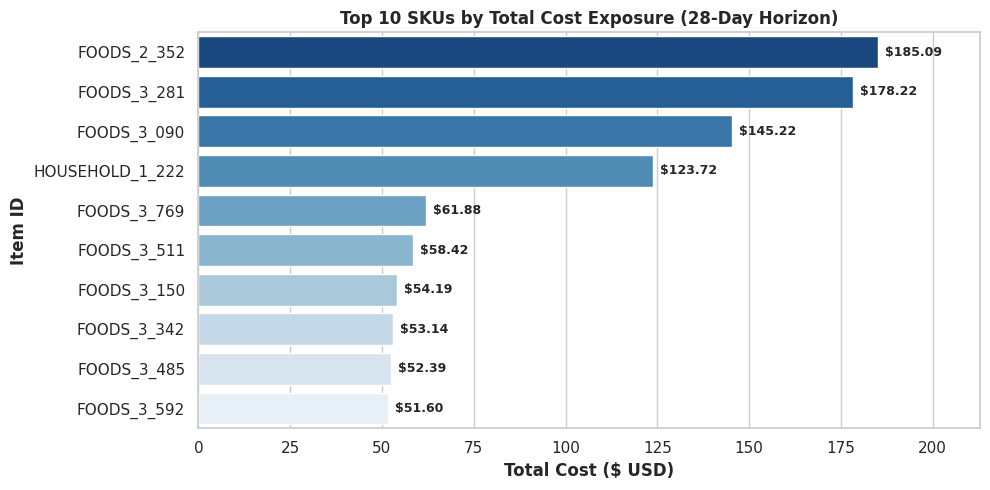

In [8]:
"""
Case Study 02 Output Formatter - Granular SKU Visualizations
Objective: Identify top cost-driving items overall and within product categories.
"""

# Set visual style for clean GitHub rendering
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

# Ensure category column exists from item_id prefix (e.g., FOODS, HOBBIES, HOUSEHOLD)
cost_summary_df["category"] = cost_summary_df["item_id"].apply(
    lambda x: x.split("_")[0]
)

# -------------------------------------------------------------------------
# Plot 1: Top 10 Most Expensive SKUs Overall
# -------------------------------------------------------------------------
top_10_overall = (
    cost_summary_df.sort_values(by="total_cost", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 5))
ax1 = sns.barplot(
    data=top_10_overall,
    x="total_cost",
    y="item_id",
    palette="Blues_r",
    hue="item_id",
    legend=False,
)

plt.title(
    "Top 10 SKUs by Total Cost Exposure (28-Day Horizon)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Total Cost ($ USD)", fontweight="bold")
plt.ylabel("Item ID", fontweight="bold")

# Add exact value labels on the end of each bar
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(
        f"${width:,.2f}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

# Adjust x-limit to fit text annotations
plt.xlim(0, top_10_overall["total_cost"].max() * 1.15)
plt.tight_layout()
plt.savefig(BASE_DIR/"case_studies/top_10_items_overall.png", dpi=300)
plt.show()



/tmp/ipykernel_134832/1039666370.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(by="total_cost", ascending=False).head(5))


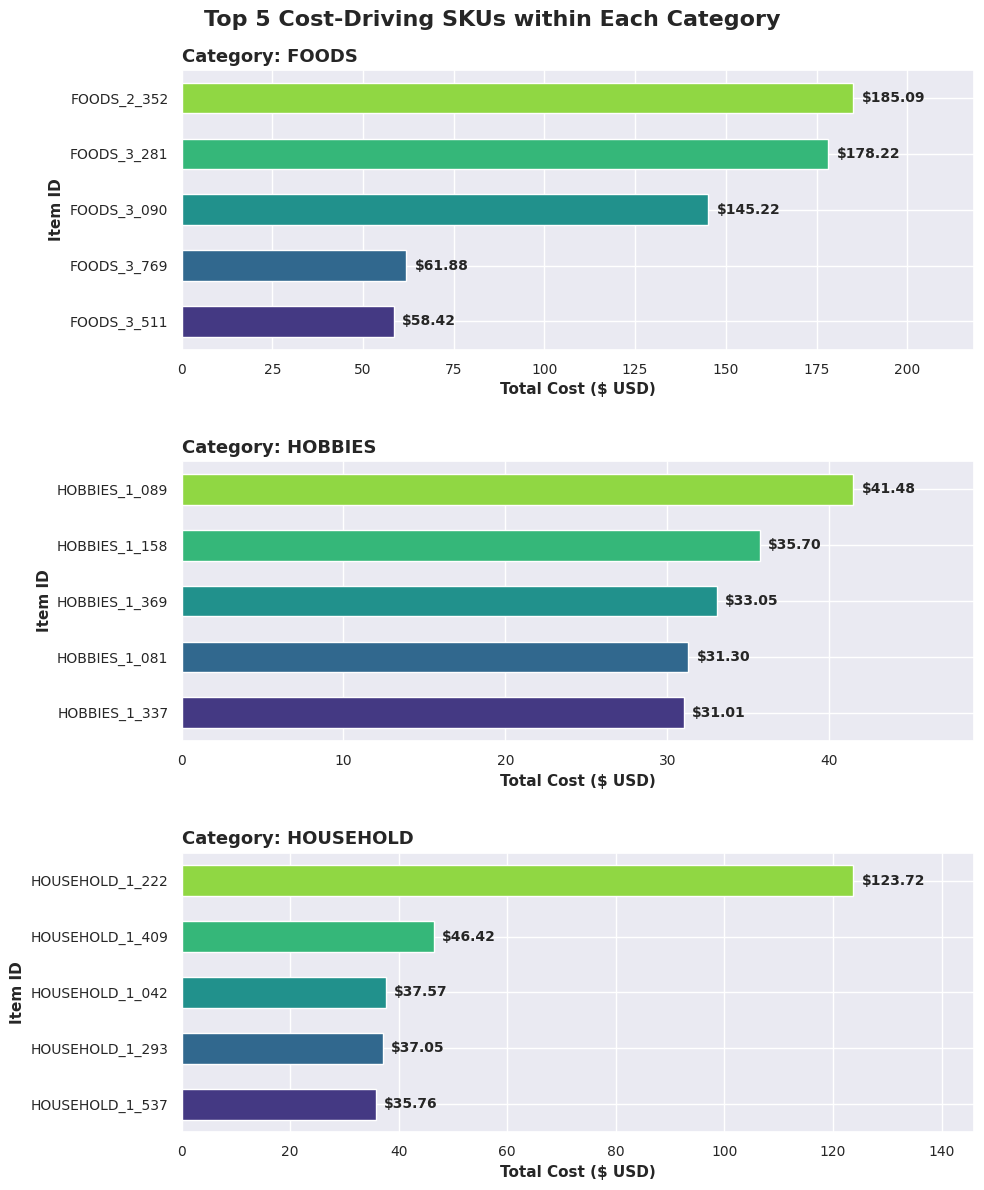

In [18]:
# 1. Extract Top 5 SKUs per Category
top_5_per_category = (
    cost_summary_df.groupby("category", group_keys=False)
    .apply(lambda x: x.sort_values(by="total_cost", ascending=False).head(5))
    .reset_index(drop=True)
)

categories = top_5_per_category["category"].unique()

# 2. Create a 3-row by 1-column layout with ample height (figsize=(10, 12))
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)
fig.suptitle(
    "Top 5 Cost-Driving SKUs within Each Category",
    fontsize=16,
    fontweight="bold",
    y=0.99,
)

# 3. Iterate through each category and build individual horizontal bar charts
for i, cat in enumerate(categories):
    ax = axes[i]

    # Filter and sort data ascending so the highest value renders at the top
    cat_data = top_5_per_category[
        top_5_per_category["category"] == cat
    ].sort_values(by="total_cost", ascending=True)

    # Render horizontal bars
    bars = ax.barh(
        cat_data["item_id"],
        cat_data["total_cost"],
        color=sns.color_palette("viridis", n_colors=5),
        height=0.55,
    )

    # Subplot Titles and Labels
    ax.set_title(f"Category: {cat}", fontsize=13, fontweight="bold", loc="left")
    ax.set_xlabel("Total Cost ($ USD)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Item ID", fontsize=11, fontweight="bold")

    # Format Ticks
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=10)

    # Add exact dollar value annotations next to each bar
    max_val = cat_data["total_cost"].max()
    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"${width:,.2f}",
            (width, bar.get_y() + bar.get_height() / 2.0),
            ha="left",
            va="center",
            xytext=(6, 0),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

    # Add 18% right padding to prevent text truncation
    ax.set_xlim(0, max_val * 1.18)

# 4. Apply tight layout with custom vertical padding between subplots
plt.tight_layout()
plt.subplots_adjust(hspace=0.4, top=0.94)
 
plt.savefig(BASE_DIR/"case_studies/top_items_per_category.png", dpi=300)
plt.show()